In [1]:
import os
import pickle
import h5py
import pywt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from matplotlib import animation
from scipy.signal import correlate2d
from scipy.stats import entropy
from IPython.display import HTML
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [2]:
H = 0.9                                              # 0.4 or 0.7 or 0.9
type_stimuli = "original"                            # 'extended' or 'original'
wbt = 'db2'                                          # 'db2' or 'haar'
review_axis = [0]                                    # [0] or [0,1,2]
if 1 in review_axis:
    level = 4
elif wbt == "haar":
    level = 9
elif wbt == "db2":
    level = 8

In [3]:
if H == 0.4:
    n_in = 1; n_fin = 11; n_event=2
if H == 0.7:
    n_in = 11; n_fin = 21; n_event=12
if H == 0.9:
    n_in = 21; n_fin = 31; n_event=22

if n_event <= 10:
    archivo_estimulo = 'ball_info04.pkl'
elif n_event <21:
    archivo_estimulo = 'ball_info07.pkl'
elif n_event > 20:
    archivo_estimulo = 'ball_info.pkl'

with open("../data/2D_stimuli_responses/"+archivo_estimulo, 'rb') as f:
    ball_info = pickle.load(f)

print(ball_info)

label = np.linspace(0,1199,5030)

def floor(x):
    return np.floor(x)

vectorized_floor = np.vectorize(floor)
label = vectorized_floor(label)
label = [int(i) for i in label]

def gaussian_2d(mean, std_dev, grid_size=100, xrange=[0,420], yrange=[0,420]):
    mu_x, mu_y = mean
    sigma_x, sigma_y = std_dev

    # Define x and y ranges
    if xrange is None:
        xrange = (mu_x - 3 * sigma_x, mu_x + 3 * sigma_x)
    if yrange is None:
        yrange = (mu_y - 3 * sigma_y, mu_y + 3 * sigma_y)

    x = np.linspace(*xrange, grid_size)
    y = np.linspace(*yrange, grid_size)
    X, Y = np.meshgrid(x, y)

    G = (1 / (2 * np.pi * sigma_x * sigma_y)) * \
        np.exp(-((X - mu_x) ** 2 / (2 * sigma_x ** 2) + (Y - mu_y) ** 2 / (2 * sigma_y ** 2)))

    return X, Y, G

gaussian_stimuli = []
for frame in range(len(ball_info)):
    mean = ball_info[frame][0]
    std_dev = ((1/2)*ball_info[frame][1],(1/2)*ball_info[frame][2])
    X, Y, G = gaussian_2d(mean, std_dev, grid_size=16)
    gaussian_stimuli.append(G)

stimuli_3d_label = np.zeros((1006,16,16))
index = [i for i in range(0,5030,5)]
for i in range(1006):
    stimuli_3d_label[i] = gaussian_stimuli[label[index[i]]] * 3000

[[(215, 215), 30, 50], [(217, 215), 30, 50], [(212, 212), 30, 50], [(212, 207), 30, 50], [(212, 199), 30, 50], [(212, 199), 30, 50], [(212, 199), 30, 50], [(210, 194), 30, 50], [(212, 194), 30, 50], [(217, 194), 30, 50], [(217, 194), 30, 50], [(221, 192), 30, 50], [(219, 187), 30, 50], [(219, 187), 30, 50], [(221, 185), 30, 50], [(221, 185), 30, 50], [(223, 183), 30, 50], [(221, 177), 30, 50], [(215, 175), 30, 50], [(209, 175), 30, 50], [(208, 169), 30, 50], [(209, 169), 30, 50], [(207, 165), 30, 50], [(205, 167), 30, 50], [(205, 167), 30, 50], [(203, 161), 30, 50], [(207, 159), 30, 50], [(207, 157), 30, 50], [(205, 155), 30, 50], [(201, 151), 30, 50], [(201, 143), 30, 50], [(197, 143), 30, 50], [(195, 139), 30, 50], [(193, 139), 30, 50], [(195, 135), 30, 50], [(194, 135), 30, 50], [(199, 135), 30, 50], [(199, 133), 30, 50], [(199, 129), 30, 50], [(195, 131), 30, 50], [(198, 129), 30, 50], [(196, 123), 30, 50], [(196, 119), 30, 50], [(193, 119), 30, 50], [(191, 119), 30, 50], [(193, 11

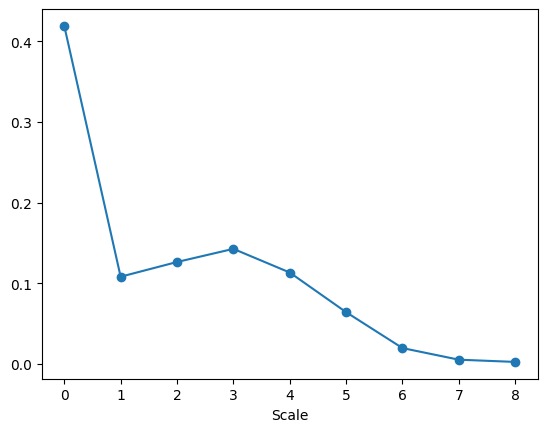

In [4]:
if type_stimuli != 'extended':
    coeffs = pywt.wavedecn(np.array(gaussian_stimuli), wavelet=wbt,axes=review_axis,level=level)
    approx = coeffs[0]

    total_energy = np.sum(np.square(approx))
    details = [np.sum(np.square(approx))]  # start with approximation energy

    for level_dict in coeffs[1:]:
        level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
        total_energy += level_energy
        details.append(level_energy)

    # Normalize energy contributions
    proportions_stimuli = [e / total_energy for e in details]
    plt.plot(proportions_stimuli,marker="o")
    plt.xlabel("Scale")
else:
    coeffs = pywt.wavedecn(stimuli_3d_label, wavelet=wbt,axes=review_axis,level=level)
    approx = coeffs[0]

    total_energy = np.sum(np.square(approx))
    details = [np.sum(np.square(approx))]  # start with approximation energy

    for level_dict in coeffs[1:]:
        level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
        total_energy += level_energy
        details.append(level_energy)

    # Normalize energy contributions
    proportions_stimuli = [e / total_energy for e in details]
    plt.plot(proportions_stimuli,marker="o")
    plt.xlabel("Scale")

## Pure response analysis

In [5]:
rep_results = {}
for n_e in range(n_in,n_fin):
    with open(f'../data/2D_stimuli_responses/{n_e}frames_5.pkl', 'rb') as f:
        videos_by_group = pickle.load(f)
    rep_results[n_e] = videos_by_group

averaged = {}

for key, values in videos_by_group.items():
    new_values = []
    for i in range(len(values)):
        if not (key == 'WT_6m' and i==1):
            ind_average = np.zeros((1006,16,16))
            for j in range(n_in,n_fin):
                ind_average += np.array(rep_results[j][key][i])
            ind_average = ind_average/10
            new_values.append(ind_average)
    averaged[key] = new_values

videos_by_group = averaged

def threshold_coeffs(coeffs, threshold):
    thresholded_coeffs = [coeffs[0]]  # Approximation coeffs at level 0 (do not threshold)

    for detail_level in coeffs[1:]:
        thresholded_level = {}
        for key, arr in detail_level.items():
            thresholded_arr = np.where(np.abs(arr) < threshold, 0, arr)
            thresholded_level[key] = thresholded_arr
        thresholded_coeffs.append(thresholded_level)

    return thresholded_coeffs


filtered_data = {}
for group_name, videos in videos_by_group.items():
    subframes = videos
    for i in range(len(videos)):
        coeffs = pywt.wavedecn(np.array(videos[i]), wavelet='db2')
        threshold = 0.01
        thresholded_coeffs = threshold_coeffs(coeffs, threshold)
        subframes[i] = pywt.waverecn(thresholded_coeffs, wavelet='db2')
    filtered_data[group_name] = subframes

correlated_denoised_videos = {}
for group_name in videos_by_group.keys():
    corr_videos = []
    for individual in videos_by_group[group_name]:
        reconstructed_video = individual
        new_video = np.multiply(np.abs(reconstructed_video),stimuli_3d_label)
        corr_videos.append(new_video)
    correlated_denoised_videos[group_name] = corr_videos

types = []
mean = []
fq = [] # first quartile
lq = []#  last quartile
sd = []
normas = []
proportion = []
outer_info = []
for group_name, videos in correlated_denoised_videos.items():
    for i in range(len(videos)):
        types.append(group_name)
        mean.append(np.mean(videos[i],axis=(1,2)))
        fq.append(np.percentile(np.abs(videos[i]),75,axis=(1,2)))
        lq.append(np.percentile(np.abs(videos[i]),90,axis=(1,2)))
        sd.append(np.std(videos[i],axis=(1,2)))
        pos = [[int(ball_info[label[frame]][0][0] /(420/16)),int(ball_info[label[frame]][0][1] /(420/16))] for frame in range(len(videos[i]))]
        norm_video=[]
        video_outer_frame = []
        frame_proportions = []
        for j in range(len(videos[i])):
            inner_frame = videos_by_group[group_name][i][j,pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4].copy()
            frame_proportions.append(np.linalg.norm(inner_frame,ord='fro'))#/np.linalg.norm(videos_by_group[group_name][i][j],ord='fro')
            outer_frame = videos_by_group[group_name][i][j].copy()
            semi_array_dim = (max(pos[j][0]-4,0),min(pos[j][0]+4,16),max(pos[j][1]-4,0),min(pos[j][1]+4,16))
            outer_frame[pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4] = np.zeros((outer_frame[pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4]).shape).copy()
            video_outer_frame.append(np.linalg.norm(outer_frame,ord='fro'))#/np.linalg.norm(videos_by_group[group_name][i][j],ord='fro')
            norm_video.append(np.linalg.norm(videos[i][j],ord='fro'))#,pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4
        coeffs = pywt.wavedecn(videos[i], wavelet=wbt,axes=review_axis,level=level)
        approx = coeffs[0]

        total_energy = np.sum(np.square(approx))
        details = [np.sum(np.square(approx))]  # start with approximation energy

        for level_dict in coeffs[1:]:
            level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
            total_energy += level_energy
            details.append(level_energy)

        # Normalize energy contributions
        proportions = [e / total_energy for e in details]
        normas.append(norm_video)
        outer_info.append(video_outer_frame)
        proportion.append(proportions)
features = {"type":types,"mean":mean,"75":fq,"90":lq,"sd":sd,"norm":normas,"inf_ratio":proportion,'outer_info' : outer_info}
summary = pd.DataFrame(features)
df = summary.copy()
df['K_L div'] = df['inf_ratio'].apply(lambda x: entropy(proportions_stimuli,x))

In [6]:
wavelet_prop = df[['type','inf_ratio','K_L div']].copy()
wavelet_prop['entropy'] = wavelet_prop['inf_ratio'].apply(entropy)
wavelet_prop['energy'] = wavelet_prop['inf_ratio'].apply(lambda x: x[3])

def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

wavelet_prop['age'] = wavelet_prop['type'].apply(age)
wavelet_prop['condition'] = wavelet_prop['type'].apply(condition)

In [7]:
from utils import experiment_based_classification

print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["energy",'age']],"age")
print("== wavelet - cond==")
experiment_based_classification(wavelet_prop[["energy",'condition']],"condition")
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["entropy",'age']],'age')
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["entropy",'condition']],'condition')
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["K_L div",'age']],'age')
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["K_L div",'condition']],'condition')

== wavelet - age==
LOOCV Accuracy 0: 43.33%
== wavelet - cond==
LOOCV Accuracy 0: 76.67%
== wavelet - age==
LOOCV Accuracy 0: 16.67%
== wavelet - age==
LOOCV Accuracy 0: 40.00%
== wavelet - age==
LOOCV Accuracy 0: 50.00%
== wavelet - age==
LOOCV Accuracy 0: 73.33%


{'0': 0.7333333333333333}

## co-activation

In [31]:
H = 0.9                                              # 0.4 or 0.7 or 0.9
type_stimuli = "original"                            # 'extended' or 'original'
wbt = 'db2'                                          # 'db2' or 'haar'
review_axis = [0]                                    # [0] or [0,1,2]
if 1 in review_axis:
    level = 4
elif wbt == "haar":
    level = 9
elif wbt == "db2":
    level = 8

In [32]:
if H == 0.4:
    n_in = 1; n_fin = 11; n_event=2
if H == 0.7:
    n_in = 11; n_fin = 21; n_event=12
if H == 0.9:
    n_in = 21; n_fin = 31; n_event=22

if n_event <= 10:
    archivo_estimulo = 'ball_info04.pkl'
elif n_event <21:
    archivo_estimulo = 'ball_info07.pkl'
elif n_event > 20:
    archivo_estimulo = 'ball_info.pkl'

with open('../data/2D_stimuli_responses/'+archivo_estimulo, 'rb') as f:
    ball_info = pickle.load(f)

print(ball_info)

label = np.linspace(0,1199,5030)

def floor(x):
    return np.floor(x)

vectorized_floor = np.vectorize(floor)
label = vectorized_floor(label)
label = [int(i) for i in label]

def gaussian_2d(mean, std_dev, grid_size=100, xrange=[0,420], yrange=[0,420]):
    mu_x, mu_y = mean
    sigma_x, sigma_y = std_dev

    # Define x and y ranges
    if xrange is None:
        xrange = (mu_x - 3 * sigma_x, mu_x + 3 * sigma_x)
    if yrange is None:
        yrange = (mu_y - 3 * sigma_y, mu_y + 3 * sigma_y)

    x = np.linspace(*xrange, grid_size)
    y = np.linspace(*yrange, grid_size)
    X, Y = np.meshgrid(x, y)

    G = (1 / (2 * np.pi * sigma_x * sigma_y)) * \
        np.exp(-((X - mu_x) ** 2 / (2 * sigma_x ** 2) + (Y - mu_y) ** 2 / (2 * sigma_y ** 2)))

    return X, Y, G

gaussian_stimuli = []
for frame in range(len(ball_info)):
    mean = ball_info[frame][0]
    std_dev = ((1/2)*ball_info[frame][1],(1/2)*ball_info[frame][2])
    X, Y, G = gaussian_2d(mean, std_dev, grid_size=16)
    gaussian_stimuli.append(G)

stimuli_3d_label = np.zeros((1006,16,16))
index = [i for i in range(0,5030,5)]
for i in range(1006):
    stimuli_3d_label[i] = gaussian_stimuli[label[index[i]]] * 3000

[[(215, 215), 30, 50], [(217, 215), 30, 50], [(212, 212), 30, 50], [(212, 207), 30, 50], [(212, 199), 30, 50], [(212, 199), 30, 50], [(212, 199), 30, 50], [(210, 194), 30, 50], [(212, 194), 30, 50], [(217, 194), 30, 50], [(217, 194), 30, 50], [(221, 192), 30, 50], [(219, 187), 30, 50], [(219, 187), 30, 50], [(221, 185), 30, 50], [(221, 185), 30, 50], [(223, 183), 30, 50], [(221, 177), 30, 50], [(215, 175), 30, 50], [(209, 175), 30, 50], [(208, 169), 30, 50], [(209, 169), 30, 50], [(207, 165), 30, 50], [(205, 167), 30, 50], [(205, 167), 30, 50], [(203, 161), 30, 50], [(207, 159), 30, 50], [(207, 157), 30, 50], [(205, 155), 30, 50], [(201, 151), 30, 50], [(201, 143), 30, 50], [(197, 143), 30, 50], [(195, 139), 30, 50], [(193, 139), 30, 50], [(195, 135), 30, 50], [(194, 135), 30, 50], [(199, 135), 30, 50], [(199, 133), 30, 50], [(199, 129), 30, 50], [(195, 131), 30, 50], [(198, 129), 30, 50], [(196, 123), 30, 50], [(196, 119), 30, 50], [(193, 119), 30, 50], [(191, 119), 30, 50], [(193, 11

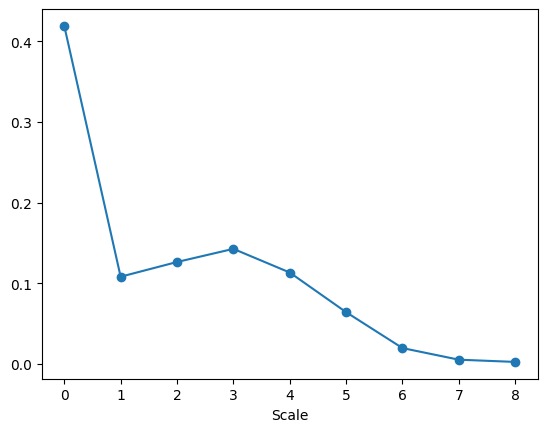

In [33]:
if type_stimuli != 'extended':
    coeffs = pywt.wavedecn(np.array(gaussian_stimuli), wavelet=wbt,axes=review_axis,level=level)
    approx = coeffs[0]

    total_energy = np.sum(np.square(approx))
    details = [np.sum(np.square(approx))]  # start with approximation energy

    for level_dict in coeffs[1:]:
        level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
        total_energy += level_energy
        details.append(level_energy)

    # Normalize energy contributions
    proportions_stimuli = [e / total_energy for e in details]
    plt.plot(proportions_stimuli,marker="o")
    plt.xlabel("Scale")
else:
    coeffs = pywt.wavedecn(stimuli_3d_label, wavelet=wbt,axes=review_axis,level=level)
    approx = coeffs[0]

    total_energy = np.sum(np.square(approx))
    details = [np.sum(np.square(approx))]  # start with approximation energy

    for level_dict in coeffs[1:]:
        level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
        total_energy += level_energy
        details.append(level_energy)

    # Normalize energy contributions
    proportions_stimuli = [e / total_energy for e in details]
    plt.plot(proportions_stimuli,marker="o")
    plt.xlabel("Scale")

In [34]:
def gaussian_2d(mean, std_dev, grid_size=100, xrange=[0,420], yrange=[0,420]):
    mu_x, mu_y = mean
    sigma_x, sigma_y = std_dev

    # Define x and y ranges
    if xrange is None:
        xrange = (mu_x - 3 * sigma_x, mu_x + 3 * sigma_x)
    if yrange is None:
        yrange = (mu_y - 3 * sigma_y, mu_y + 3 * sigma_y)

    x = np.linspace(*xrange, grid_size)
    y = np.linspace(*yrange, grid_size)
    X, Y = np.meshgrid(x, y)

    G = (1 / (2 * np.pi * sigma_x * sigma_y)) * \
        np.exp(-((X - mu_x) ** 2 / (2 * sigma_x ** 2) + (Y - mu_y) ** 2 / (2 * sigma_y ** 2)))

    return X, Y, G

gaussian_stimuli = []
for frame in range(len(ball_info)):
    mean = ball_info[frame][0]
    std_dev = ((1/2)*ball_info[frame][1],(1/2)*ball_info[frame][2])
    X, Y, G = gaussian_2d(mean, std_dev, grid_size=16)
    gaussian_stimuli.append(G)

stimuli_3d_label = np.zeros((1006,16,16))
index = [i for i in range(0,5030,5)]
for i in range(1006):
    stimuli_3d_label[i] = gaussian_stimuli[label[index[i]]] * 3000

correlated_denoised_videos = {}
for group_name in videos_by_group.keys():
    corr_videos = []
    for individual in videos_by_group[group_name]:
        reconstructed_video = individual
        new_video = np.multiply(np.abs(reconstructed_video),stimuli_3d_label)
        corr_videos.append(new_video)
    correlated_denoised_videos[group_name] = corr_videos

types = []
mean = []
normas = []
info_proportion = []
outer_info = []
wb_dist = []
for group_name, videos in correlated_denoised_videos.items():
    for i in range(len(videos)):
        types.append(group_name)
        mean.append(np.sum(videos[i],axis=(0,1,2)))
        pos = [[int(ball_info[label[frame]][0][0] /(420/16)),int(ball_info[label[frame]][0][1] /(420/16))] for frame in range(len(videos[i]))]
        norm_video=[]
        video_outer_frame = []
        frame_proportions = []
        for j in range(len(videos[i])):
            min_x = max(pos[j][0]-4,0); max_x = min(pos[j][0]+4,15)
            min_y = max(pos[j][1]-4,0); max_y = min(pos[j][1]+4,15)
            inner_frame = videos_by_group[group_name][i][j,min_x:max_x,min_y:max_y].copy()
            frame_proportions.append(np.sum(np.abs(inner_frame))/np.sum(np.abs(videos_by_group[group_name][i][j])))
            outer_frame = videos_by_group[group_name][i][j].copy()
            #outer_frame[pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4] = np.zeros((8,8)).copy()
            #video_outer_frame.append(np.linalg.norm(outer_frame,ord='fro')/np.linalg.norm(videos_by_group[group_name][i][j],ord='fro'))
            norm_video.append(np.linalg.norm(videos[i][j],ord='fro'))#,pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4
        normas.append(np.mean(norm_video))
        #outer_info.append(np.mean(video_outer_frame))
        info_proportion.append(np.mean(frame_proportions))
        coeffs = pywt.wavedecn(videos[i], wavelet=wbt,axes=review_axis,level=level)
        approx = coeffs[0]

        total_energy = np.sum(np.square(approx))
        details = [np.sum(np.square(approx))]  # start with approximation energy

        for level_dict in coeffs[1:]:
            level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
            total_energy += level_energy
            details.append(level_energy)

        # Normalize energy contributions
        proportions = [e / total_energy for e in details]
        wb_dist.append(proportions)

features = {"type":types,"mean":mean,"norm":normas,"inf_ratio":info_proportion,'wb_dist':wb_dist}
summary = pd.DataFrame(features)
df = summary.copy()
df['energy'] = df['wb_dist'].apply(lambda x: x[1])


In [35]:
df['age'] = df['type'].apply(age)
df['condition'] = df['type'].apply(condition)

print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["energy",'age']],"age")
print("== wavelet - cond==")
experiment_based_classification(wavelet_prop[["energy",'condition']],"condition")


== wavelet - age==
LOOCV Accuracy 0: 43.33%
== wavelet - cond==
LOOCV Accuracy 0: 53.33%


{'0': 0.5333333333333333}

## Hurst parameter estimator

In [21]:
import pickle
from typing import List, Tuple

import numpy as np
import pandas as pd
from scipy.ndimage import center_of_mass
from scipy.stats import gaussian_kde
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# ALPHA = -0.23791952079438267
# BETA  =  0.27023111858695703

# GROUPS = {
#     "5xFAD_3m": ["MR-0644", "MR-0645", "MR-0648", "MR-0649", "MR-0661", "MR-0663", "MR-0667"],
#     "5xFAD_6m": ["MR-0659-t1", "MR-0659-t2", "MR-0676", "MR-0657-t2", "MR-0674", "MR-0656"],
#     "WT_3m":    ["MR-0677", "MR-0678", "MR-0662", "MR-0665", "MR-0668", "MR-0669"],
#     "WT_6m":    ["MR-0679", "MR-0655", "MR-0658", "MR-0654-t1"],
# }

# EVENT_RANGES = {
#     "h4": range(21, 31),
#     "h7": range(11, 21),
#     "h9": range(21, 31),
# }

# def age(ind):
#     if '3m' in ind:
#         return 'young'
#     else:
#         return 'old'

# def condition(ind):
#     if '5xFAD' in ind:
#         return '5xFAD'
#     else:
#         return 'Wild-Type'

# def kde_entropy(x, base=np.e, use_self=True, bw="silverman", n_mc=5000):
#     x = np.asarray(x, float).ravel()
#     if isinstance(bw, (int, float)):
#         bw = float(bw) / np.std(x, ddof=1)
#     kde = gaussian_kde(x, bw_method=bw)
#     if use_self:
#         log_density = np.log(kde.evaluate(kde.resample(n_mc)))
#     else:
#         log_density = np.log(kde.evaluate(x))
#     return -np.mean(log_density) / np.log(base)


# def rescale_fbm_like(x):
#     x = np.asarray(x, float).ravel()
#     x0 = x - x[0]
#     dx = np.diff(x0)
#     dx -= dx.mean()
#     std = dx.std(ddof=1)
#     if std == 0:
#         raise ValueError("Zero variance in increments; cannot rescale.")
#     return np.r_[0.0, np.cumsum(dx / std)]


# def estimate_hurst(x, win=100, step=100, alpha=ALPHA, beta=BETA):
#     x = np.asarray(x, float).ravel()
#     if len(x) < win:
#         return np.nan
#     x = rescale_fbm_like(x)
#     entropies = [
#         kde_entropy(x[j : j + win], use_self=True, bw="silverman")
#         for j in range(0, 1000, step)
#     ]
#     return alpha + beta * np.mean(entropies)


# def load_and_average(event_range):
#     rep_results = {}
#     for n_event in event_range:
#         with open(f"../data/2D_stimuli_responses/{n_event}frames_5.pkl", "rb") as f:
#             rep_results[n_event] = pickle.load(f)
#     videos_by_group = rep_results[max(event_range)]
#     averaged = {}
#     for group, animals in videos_by_group.items():
#         averaged[group] = [
#             np.array([rep_results[n][group][i] for n in event_range]).mean(axis=0)
#             for i in range(len(animals))
#         ]
#     return averaged


# def compute_com_trajectories(series_by_group):
#     return {
#         group: [
#             np.array([center_of_mass(np.abs(frame)) for frame in video])
#             for video in animals
#         ]
#         for group, animals in series_by_group.items()
#     }


# def estimate_hurst_xy(com_by_group):
#     X_h, Y_h = {}, {}
#     for group, animals in com_by_group.items():
#         X_h[group] = [estimate_hurst(traj[:, 0]) for traj in animals]
#         Y_h[group] = [estimate_hurst(traj[:, 1]) for traj in animals]
#     return X_h, Y_h


# def flatten_hurst_estimates(X_h, Y_h):
#     X_flat, Y_flat, labels = [], [], []
#     for group in X_h:
#         for x_val, y_val in zip(X_h[group], Y_h[group]):
#             X_flat.append(x_val)
#             Y_flat.append(y_val)
#             labels.append(group)
#     return X_flat, Y_flat, labels


# def run_pipeline(event_range):
#     averaged      = load_and_average(event_range)
#     com_trajs     = compute_com_trajectories(averaged)
#     X_h, Y_h      = estimate_hurst_xy(com_trajs)
#     return flatten_hurst_estimates(X_h, Y_h)


# datasets = {
#     name: run_pipeline(event_range)
#     for name, event_range in EVENT_RANGES.items()
# }


# def experiment_based_classification(df: pd.DataFrame, label_col: str) -> dict:
#     X = np.asarray(df.drop(columns=[label_col])).reshape(-1, 1)
#     y = np.asarray(df[label_col])

#     pipeline = Pipeline([
#         ("scaler", StandardScaler()),
#         ("svc",    SVC(probability=False)),
#     ])

#     param_grid = [
#         {"svc__kernel": ["linear"],  "svc__C": [0.01, 0.1, 1, 10, 100]},
#         {"svc__kernel": ["rbf"],     "svc__C": [0.01, 0.1, 1, 10, 100],
#          "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10]},
#         {"svc__kernel": ["poly"],    "svc__C": [0.01, 0.1, 1, 10, 100],
#          "svc__degree": [2, 3, 4, 5],
#          "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1]},
#         {"svc__kernel": ["sigmoid"], "svc__C": [0.01, 0.1, 1, 10, 100],
#          "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1]},
#     ]

#     loo = LeaveOneOut()
#     y_true, y_pred = [], []

#     for train_idx, test_idx in loo.split(X):
#         grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
#         grid_search.fit(X[train_idx], y[train_idx])
#         y_pred.append(grid_search.best_estimator_.predict(X[test_idx])[0])
#         y_true.append(y[test_idx][0])

#     return accuracy_score(y_true, y_pred)


svm_results = {}
for name, (X_vals, Y_vals, labels) in datasets.items():
    df = pd.DataFrame({"H_x": X_vals, "label": pd.Series(labels).apply(age)})
    acc = experiment_based_classification(df, label_col="label")
    svm_results[name] = acc
    print(f"[{name}] AGE LOOCV Accuracy X-axis: {acc:.2%}")
    df = pd.DataFrame({"H_y": Y_vals, "label": pd.Series(labels).apply(age)})
    acc = experiment_based_classification(df, label_col="label")
    svm_results[name] = acc
    print(f"[{name}] AGE LOOCV Accuracy Y-axis: {acc:.2%}")

c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[h4] AGE LOOCV Accuracy X-axis: 51.61%
[h4] AGE LOOCV Accuracy Y-axis: 67.74%
[h7] AGE LOOCV Accuracy X-axis: 54.84%
[h7] AGE LOOCV Accuracy Y-axis: 41.94%
[h9] AGE LOOCV Accuracy X-axis: 67.74%
[h9] AGE LOOCV Accuracy Y-axis: 64.52%


In [22]:
svm_results = {}
for name, (X_vals, Y_vals, labels) in datasets.items():
    df = pd.DataFrame({"H_x": X_vals, "label": pd.Series(labels).apply(condition)})
    acc = experiment_based_classification(df, label_col="label")
    svm_results[name] = acc
    print(f"[{name}] Condition LOOCV Accuracy X-axis: {acc:.2%}")
    df = pd.DataFrame({"H_y": Y_vals, "label": pd.Series(labels).apply(condition)})
    acc = experiment_based_classification(df, label_col="label")
    svm_results[name] = acc
    print(f"[{name}] Condition LOOCV Accuracy Y-axis: {acc:.2%}")

[h4] Condition LOOCV Accuracy X-axis: 58.06%
[h4] Condition LOOCV Accuracy Y-axis: 48.39%
[h7] Condition LOOCV Accuracy X-axis: 51.61%
[h7] Condition LOOCV Accuracy Y-axis: 54.84%
[h9] Condition LOOCV Accuracy X-axis: 22.58%
[h9] Condition LOOCV Accuracy Y-axis: 54.84%


## 2D Replication

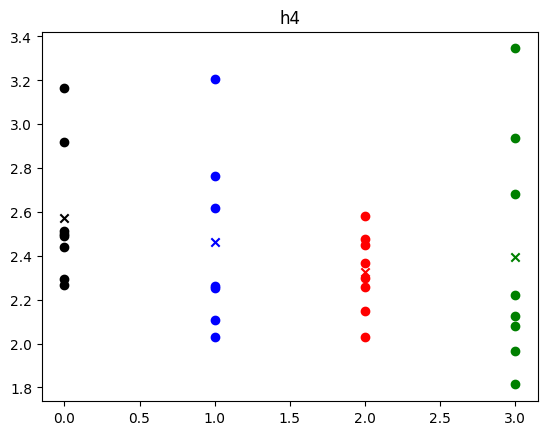

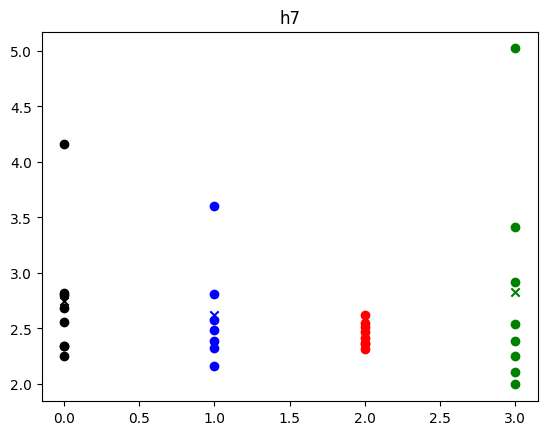

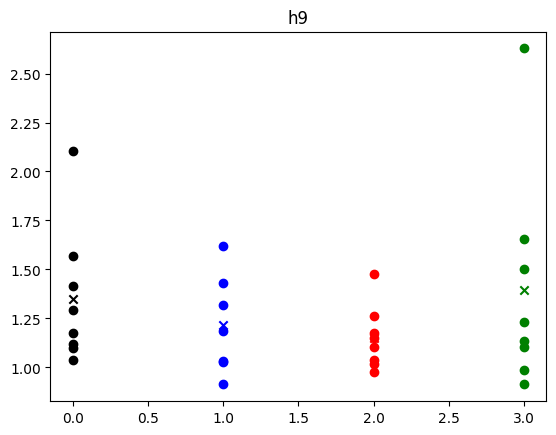

[h4] [age] LOOCV Accuracy: 58.06%


KeyboardInterrupt: 

In [8]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


EVENT_RANGES = {
    "h4": (range(1, 11), "ball_info04.pkl"),
    "h7": (range(11, 21), "ball_info07.pkl"),
    "h9": (range(21, 31), "ball_info.pkl"),
}

GROUP_COLORS = {
    "5xFAD_3m": "r",
    "5xFAD_6m": "g",
    "WT_3m":    "k",
    "WT_6m":    "b",
}
 
AGE_MAP = {
    "5xFAD_3m": "3m",
    "5xFAD_6m": "6m",
    "WT_3m":    "3m",
    "WT_6m":    "6m",
}
 
CONDITION_MAP = {
    "5xFAD_3m": "5xFAD",
    "5xFAD_6m": "5xFAD",
    "WT_3m":    "WT",
    "WT_6m":    "WT",
}
 
 
def load_and_average(event_range):
    rep_results = {}
    for n_event in event_range:
        with open(f"../data/2D_stimuli_responses/{n_event}frames_5.pkl", "rb") as f:
            rep_results[n_event] = pickle.load(f)
    videos_by_group = rep_results[max(event_range)]
    return {
        group: [
            np.array([rep_results[n][group][i] for n in event_range]).mean(axis=0)
            for i in range(len(animals))
        ]
        for group, animals in videos_by_group.items()
    }
 
 
def compute_com_displacements(averaged_series):
    displacements = {}
    for group, animals in averaged_series.items():
        displacements[group] = []
        for video in animals:
            com = np.array([center_of_mass(np.abs(frame)) for frame in video])
            displacements[group].append(
                np.column_stack([np.diff(com[:, 0]), np.diff(com[:, 1])])
            )
    return displacements
 
 
def load_ball_displacements(filepath, n_frames=1006, spatial_scale=16/420):
    with open('../data/2D_stimuli_responses/'+filepath, "rb") as f:
        ball_info = pickle.load(f)
    ball_xy = np.array([[arr[0][0] * spatial_scale, arr[0][1] * spatial_scale]
                        for arr in ball_info])
    frame_indices = np.floor(np.linspace(0, 1199, n_frames - 1)).astype(int)
    ball_sampled  = ball_xy[frame_indices]
    return np.column_stack([np.diff(ball_sampled[:, 0]), np.diff(ball_sampled[:, 1])])
 
 
def corr_2d(X,Y):
    x1 = np.abs(X[:,0])
    x2 = np.abs(X[:,1])
    y1 = np.abs(Y[:,0])
    y2 = np.abs(Y[:,1])
    return np.multiply(x1,y1),np.multiply(x2,y2)
 
 
def compute_correlation_norms(com_displacements, ball_displacements):
    return {
        group: [
            float(np.sqrt(np.sum(np.square(corr_2d(disp[:-1], ball_displacements)))))
            for disp in animals
        ]
        for group, animals in com_displacements.items()
    }
 
 
def plot_correlation_norms(correlation_norms, title=""):
    for k, (group, norms) in enumerate(correlation_norms.items()):
        color = GROUP_COLORS[group]
        for norm in norms:
            plt.scatter(k, norm, color=color, label=group)
        plt.scatter(k, np.mean(norms), marker="x", color=color)
    plt.title(title)
    plt.show()
    plt.close()
 
 
def flatten_norms(correlation_norms, label_map):
    norms, labels = [], []
    for group, group_norms in correlation_norms.items():
        norms.extend(group_norms)
        labels.extend([label_map[group]] * len(group_norms))
    return norms, labels
 
 
def experiment_based_classification(df: pd.DataFrame, label_col: str) -> float:
    X = np.asarray(df.drop(columns=[label_col])).reshape(-1, 1)
    y = np.asarray(df[label_col])
 
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svc",    SVC(probability=False)),
    ])
 
    param_grid = [
        {"svc__kernel": ["linear"],  "svc__C": [0.01, 0.1, 1, 10, 100]},
        {"svc__kernel": ["rbf"],     "svc__C": [0.01, 0.1, 1, 10, 100],
         "svc__gamma":  ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10]},
        {"svc__kernel": ["poly"],    "svc__C": [0.01, 0.1, 1, 10, 100],
         "svc__degree": [2, 3, 4, 5],
         "svc__gamma":  ["scale", "auto", 1e-3, 1e-2, 1e-1, 1]},
        {"svc__kernel": ["sigmoid"], "svc__C": [0.01, 0.1, 1, 10, 100],
         "svc__gamma":  ["scale", "auto", 1e-3, 1e-2, 1e-1, 1]},
    ]
 
    loo = LeaveOneOut()
    y_true, y_pred = [], []
 
    for train_idx, test_idx in loo.split(X):
        grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
        grid_search.fit(X[train_idx], y[train_idx])
        y_pred.append(grid_search.best_estimator_.predict(X[test_idx])[0])
        y_true.append(y[test_idx][0])
 
    return accuracy_score(y_true, y_pred)
 
 
datasets = {}
for name, (event_range, ball_file) in EVENT_RANGES.items():
    averaged           = load_and_average(event_range)
    com_disps          = compute_com_displacements(averaged)
    ball_displacements = load_ball_displacements(ball_file)
    corr_norms         = compute_correlation_norms(com_disps, ball_displacements)
    datasets[name]     = corr_norms
    plot_correlation_norms(corr_norms, title=name)
 
for name, corr_norms in datasets.items():
    for split_name, label_map in [("age", AGE_MAP), ("condition", CONDITION_MAP)]:
        norms, labels = flatten_norms(corr_norms, label_map)
        df = pd.DataFrame({"corr_norm": norms, "label": labels})
        acc = experiment_based_classification(df, label_col="label")
        print(f"[{name}] [{split_name}] LOOCV Accuracy: {acc:.2%}")

## Results

|       | Wavelet | Entropy | KL Div | Co-Act | Hurst X | Hurst Y | 2D Rep |
|-------|---------|---------|--------|--------|---------|---------|--------|
| h4 Age| 63.33%  | <span style="background-color:#90EE90">70.00%</span> | 56.67% | 43.33% | 51.61%  | <span style="background-color:#90EE90">67.74%</span> | 58.06% |
| h7 Age| 43.33%  | 56.67%  | 33.33% | 43.33% | 54.84%  | 41.94%  | <span style="background-color:#90EE90">61.29%</span> |
| h9 Age| 43.33%  | 16.67%  | 50.00% | <span style="background-color:#90EE90">63.33%</span> | <span style="background-color:#90EE90">67.74%</span> | 64.52% | 32.26% |
| h4 Cond| 50.00% | 50.00%  | 43.33% | 53.33% | 58.06%  | 48.39%  | 51.61% |
| h7 Cond| 53.33% | 53.33%  | <span style="background-color:#90EE90">66.67%</span> | 53.33% | 51.61%  | 54.84%  | 45.16% |
| h9 Cond| <span style="background-color:#00FF00">76.67%</span> | 40.00% | <span style="background-color:#90EE90">73.33%</span> | 50.00% | 22.58%  | 54.84%  | 29.03% |
